Imports

In [1]:
import slicetca 
import torch 
import numpy as np 
import pandas as pd 
import pickle
import scipy.ndimage as spnd 
from scipy import interpolate
import scipy.stats as sps
import matplotlib.pyplot as plt
import matplotlib 



Loading Data (Start from 1 moth)

In [2]:
data_path = '/home/doshna/Desktop/Vahid_MP'
moth = '2024_11_08'
muscle_names = ['lax','lba','lsa','ldvm','ldlm','rdlm','rdvm','rsa','rba','rax']
ft_names = ['fx','fy','fz','tx','ty','tz']
low = pd.read_csv(f'{data_path}/{moth}_LOW.csv')
low_spikes = low[muscle_names].to_numpy()
high = pd.read_csv(f'{data_path}/{moth}_HIGH.csv')
high_spikes = high[muscle_names].to_numpy()
dat = np.zeros((2,10,100000))
dat[0,:,:] = low_spikes.T
dat[1,:,:] = high_spikes.T

low_ft = low[ft_names].to_numpy()
high_ft = high[ft_names].to_numpy()
ft_dat = np.zeros((2,6,100000))
ft_dat[0,:,:] = low_ft.T
ft_dat[1,:,:] = high_ft.T

ft_dat = ft_dat[:,[5],:]  # only tz for now


Preprocess data 
smooth spikse with 1d gausion sigma of 10 samples (1 ms for precision)
min-max scale for each neuron (that is how they do it idk)

In [3]:
dat = spnd.gaussian_filter1d(dat, sigma=10, axis=-1) 
dat = np.array([d/d.max() for d in np.array([d-d.min() for d in dat])])

Okay Lets Run slide TCA

In [4]:
# use cuda 
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
# data to torch tensor 
dat_tensor = torch.tensor(dat,device=device,dtype=torch.float32)

Using device: cuda


sliceTCA decomp is initialized with random weights between 0 and 1 (for non negative) 
so lets rescale the data so intial weights have similar magnitude as the data


In [5]:
dat_tensor = dat_tensor / dat_tensor.std()

**Fit the model** 


call decompose() function, takes data tensor and number of components as the inputs, 
call non negative weights 
learning rate for smooth decreasing losses, 
max iters 
stop criterian (min_std) estimates convergence based of std of losses over recent iters 
seed 


In [6]:
components, model = slicetca.decompose(dat_tensor,
                                        number_components=(1,4,2),
                                        positive=True,
                                        learning_rate=5*10**-3,
                                        min_std=10**-5,
                                        max_iter=10000,
                                        seed=0)

The model converged. Loss: 0.05716519430279732 :  30%|██▉       | 2988/10000 [00:44<01:45, 66.74it/s]


See if it converged well

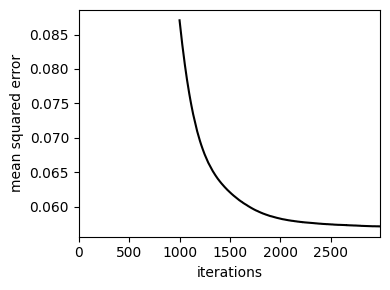

In [7]:

plt.figure(figsize=(4,3), dpi=100)
plt.plot(np.arange(1000,len(model.losses)), model.losses[1000:], 'k')
plt.xlabel('iterations')
plt.ylabel('mean squared error')
plt.xlim(0,len(model.losses))
plt.tight_layout()

We Can plot the Components now

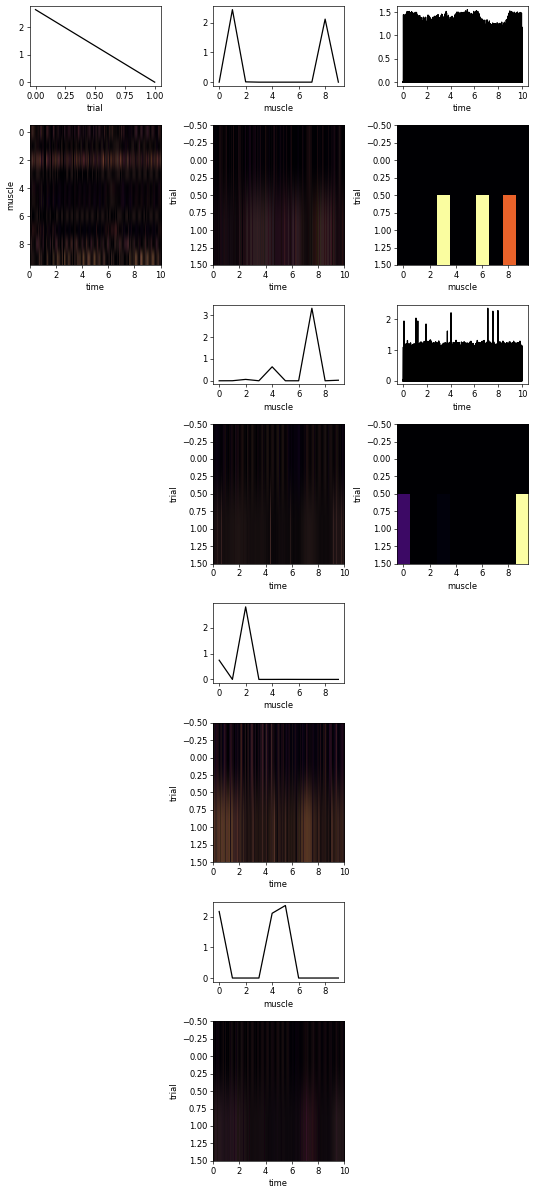

In [8]:
axes = slicetca.plot(model,
            variables=('trial','muscle','time'),
            colors=(None,None,None),
            ticks = (None,None,np.linspace(0,100000,6)),
            tick_labels=(None,None,['0','2','4','6','8','10']),
            quantile=0.99)


Reconstruct the data from fitted model 

In [9]:
recon_full = model.construct().numpy(force=True)
print(recon_full.shape)

(2, 10, 100000)


In [10]:
dat_tensor_reshaped = dat_tensor.reshape(10, -1)
recon_mus = model.construct_single_partition(partition=1).numpy(force=True).reshape(10,-1)

model.get_components()[1][0].shape
mus_weight = model.get_components()[1][0].cpu().numpy()
d_t_r = dat_tensor_reshaped.cpu().numpy()
lat = recon_mus.T @ mus_weight.T
new_lat = np.zeros((lat.shape[0]//400, lat.shape[1]))
for i in range(new_lat.shape[0]):
    new_lat[i,:] = lat[i*400:(i+1)*400,:].mean(axis=0)

latpre = lat[:100000,:]
latpost = lat[-100000:,:]

In [12]:
lowb = low['wb'].to_numpy().reshape(100000,1)
tmp = np.concatenate((latpre, lowb), axis=1)
lowlat = pd.DataFrame(tmp, columns=['Dim1','Dim2','Dim3','Dim4','Wb'])
hiwb = high['wb'].to_numpy().reshape(100000,1)
tmp = np.concatenate((latpost, hiwb), axis=1)
hilat = pd.DataFrame(tmp, columns=['Dim1','Dim2','Dim3','Dim4','Wb'])

In [21]:
norm_wb_low = np.zeros((np.max(lowlat['Wb'].to_numpy().astype(int))+1,400,4))
for i in range(np.max(lowlat['Wb'].to_numpy().astype(int))+1):
    pts = lowlat.loc[lowlat['Wb']==i][['Dim1','Dim2','Dim3','Dim4']].to_numpy()
    t = np.linspace(0,1,pts.shape[0])
    new_t = np.linspace(0,1,400)
    f = interpolate.interp1d(
        t,
        pts,
        kind='cubic',
        axis=0,

    )
    resamp = f(new_t)
    norm_wb_low[i,:,:] = resamp
norm_wb_high = np.zeros((np.max(hilat['Wb'].to_numpy().astype(int))+1,400,4))
for i in range(np.max(hilat['Wb'].to_numpy().astype(int))+1):
    pts = hilat.loc[hilat['Wb']==i][['Dim1','Dim2','Dim3','Dim4']].to_numpy()
    t = np.linspace(0,1,pts.shape[0])
    new_t = np.linspace(0,1,400)
    f = interpolate.interp1d(
        t,
        pts,
        kind='cubic',
        axis=0,

    )
    resamp = f(new_t)
    norm_wb_high[i,:,:] = resamp

In [22]:

lowlat['yaw'] = ft_dat[0,0,:]
hilat['yaw'] = ft_dat[1,0,:]
lowlat['mean_yaw'] = lowlat.groupby('Wb')['yaw'].transform('mean')
lowlat['yaw_quant'] = pd.qcut(
    lowlat['mean_yaw'],
    q=5,              # number of quantiles (quartiles)
    labels=False      # 0,1,2,3 instead of intervals
)
hilat['mean_yaw'] = hilat.groupby('Wb')['yaw'].transform('mean')
hilat['yaw_quant'] = pd.qcut(
    hilat['mean_yaw'],
    q=5,              # number of quantiles (quartiles)
    labels=False      # 0,1,2,3 instead of intervals
)  

wb_means_low=lowlat[['Wb' ,'mean_yaw','yaw_quant']].drop_duplicates().sort_values('Wb').reset_index(drop=True)
wb_means_high=hilat[['Wb' ,'mean_yaw','yaw_quant']].drop_duplicates().sort_values('Wb').reset_index(drop=True)
wb_means_low['mat'] =  [norm_wb_low[i] for i in range(norm_wb_low.shape[0])] 
wb_means_high['mat'] =  [norm_wb_high[i] for i in range(norm_wb_high.shape[0])]


In [23]:
results_low = {}
for q in wb_means_low['yaw_quant'].unique():
    matrices_q = wb_means_low.loc[wb_means_low['yaw_quant'] == q, 'mat'].to_list()
    X = np.stack(matrices_q, axis=0)
    mean_mat = X.mean(axis=0)
    std_mat = X.std(axis=0) / np.sqrt(X.shape[0])
    
    results_low[q] = {'mean': mean_mat, 'std': std_mat}
results_high = {}
for q in wb_means_high['yaw_quant'].unique():
    matrices_q = wb_means_high.loc[wb_means_high['yaw_quant'] == q, 'mat'].to_list()
    X = np.stack(matrices_q, axis=0)
    mean_mat = X.mean(axis=0)
    std_mat = X.std(axis=0) / np.sqrt(X.shape[0])
    
    results_high[q] = {'mean': mean_mat, 'std': std_mat}

In [24]:

def std_tube(mean_xyz, std_xyz, n_circle=16):

    T = mean_xyz.shape[0]

    theta = np.linspace(0, 2*np.pi, n_circle)

    xs = []
    ys = []
    zs = []

    for i in range(T):

        mx, my, mz = mean_xyz[i]
        sx, sy, sz = std_xyz[i]

        # Ellipse cross-section (axis-aligned)
        x = mx + sx * np.cos(theta)
        y = my + sy * np.sin(theta)
        z = np.full_like(theta, mz)

        xs.append(x)
        ys.append(y)
        zs.append(z)

    return np.array(xs), np.array(ys), np.array(zs)

/tmp/ipykernel_87523/4018657704.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


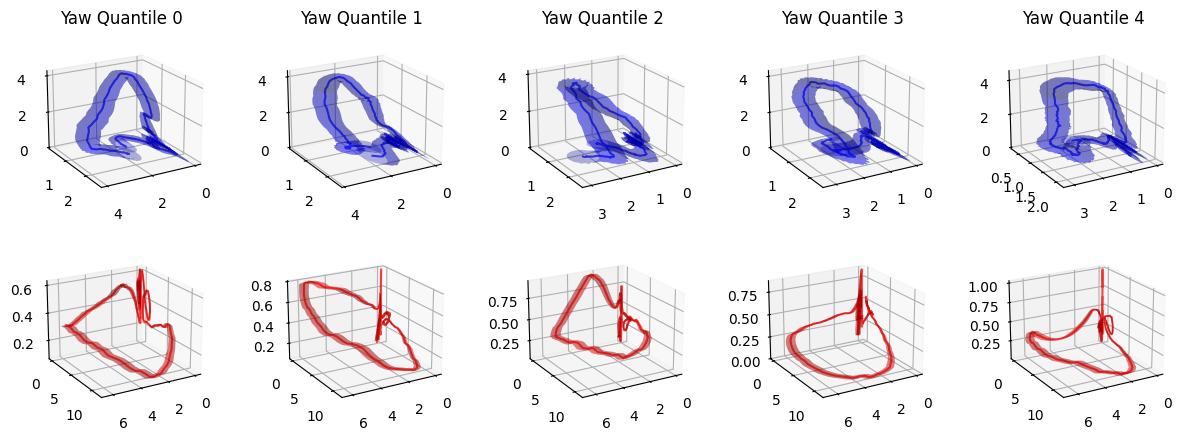

In [26]:
fig = plt.figure(figsize=(15,5))
for i in range(5):
    l = results_low[i]['mean']
    h = results_high[i]['mean']
    xl,yl,zl = std_tube(l[:,:3], results_low[i]['std'][:,:3])
    xh,yh,zh = std_tube(h[:,:3], results_high[i]['std'][:,:3])
    ax = fig.add_subplot(2,5,i+1, projection='3d')
    ax.set_title(f'Yaw Quantile {i}')
    ax.plot(l[:,0], l[:,1],l[:,2], c='b',alpha=0.7)
    ax.plot_surface(
    xl, yl, zl,
    alpha=0.3,
    linewidth=0,
    antialiased=True,color='b'
    )   
    ax.view_init(20,60)

    ax = fig.add_subplot(2,5,i+6, projection='3d')

    ax.plot(h[:,0], h[:,1],h[:,2], c='r',alpha=0.7)
    ax.plot_surface(
    xh, yh, zh,
    alpha=0.3,
    linewidth=0,
    antialiased=True,color='r'
    )
    ax.view_init(20,60)
fig.show()


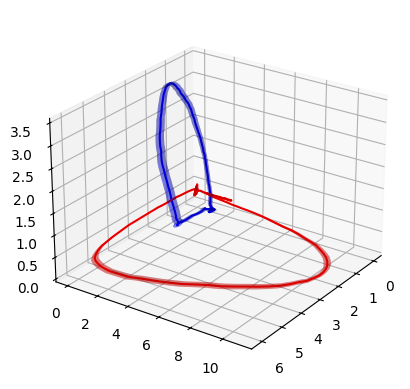

In [28]:
mnwl = np.mean(norm_wb_low, axis=0)
snwl = np.std(norm_wb_low, axis=0) / np.sqrt(norm_wb_low.shape[0])
mnwh = np.mean(norm_wb_high, axis=0)
snwh = np.std(norm_wb_high, axis=0) / np.sqrt(norm_wb_high.shape[0])
xs, ys, zs = std_tube(mnwl[:,:3], snwl[:,:3], n_circle=16)
xhs,ysh,zhs = std_tube(mnwh[:,:3], snwh[:,:3], n_circle=16)
plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(mnwl[:,0], mnwl[:,1], mnwl[:,2], 'b')
ax.plot_surface(
    xs, ys, zs,
    alpha=0.3,
    linewidth=0,
    antialiased=True,color='b'
)
ax.plot3D(mnwh[:,0], mnwh[:,1], mnwh[:,2], 'r')
ax.plot_surface(
    xhs, ysh, zhs,
    alpha=0.3,
    linewidth=0,
    antialiased=True,color='r'
)
ax.view_init(25,35)

plt.show()

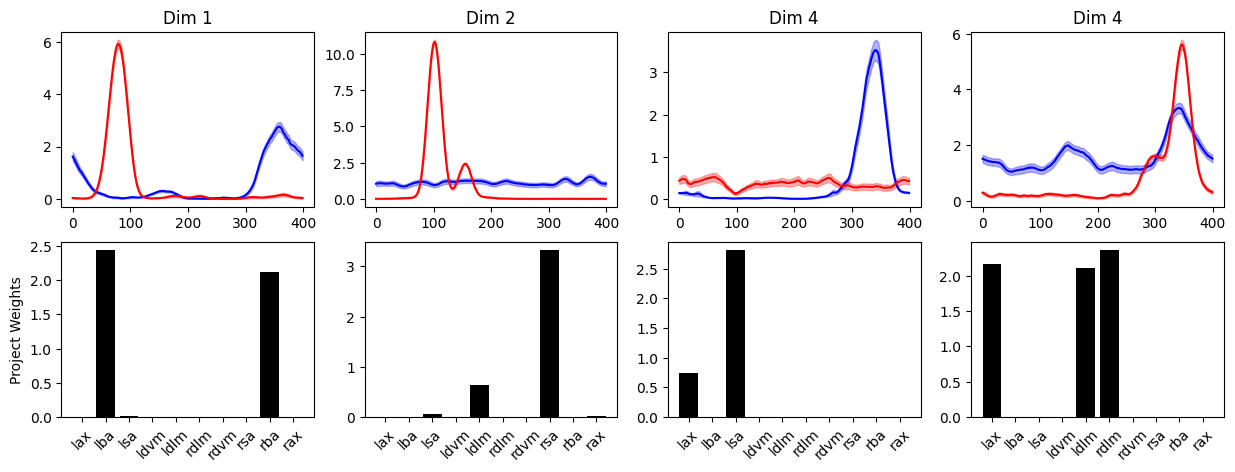

In [29]:

f = plt.figure(figsize=(15,5)) 
ax = f.add_subplot(241)
ax.plot(mnwl[:,0], label='Low Wb Dim 1', color='b')
ax.plot(mnwh[:,0], label='High Wb Dim 1', color='r')
ax.fill_between(np.arange(400), mnwl[:,0]-snwl[:,0], mnwl[:,0]+snwl[:,0], color='b', alpha=0.3)
ax.fill_between(np.arange(400), mnwh[:,0]-snwh[:,0], mnwh[:,  0]+snwh[:,0], color='r', alpha=0.3)
ax.set_title('Dim 1')
ax = f.add_subplot(242)
ax.plot(mnwl[:,1], label='Low Wb Dim 2', color='b')
ax.plot(mnwh[:,1], label='High Wb Dim 2', color='r')
ax.fill_between(np.arange(400), mnwl[:,1]-snwl[:,1], mnwl[:,1]+snwl[:,1], color='b', alpha=0.3)
ax.fill_between(np.arange(400), mnwh[:,1]-snwh[:,1], mnwh[:,  1]+snwh[:,1], color='r', alpha=0.3)
ax.set_title('Dim 2')
ax = f.add_subplot(243)
ax.plot(mnwl[:,2], label='Low Wb Dim 3', color='b')
ax.plot(mnwh[:,2], label='High Wb Dim 3', color='r')
ax.fill_between(np.arange(400), mnwl[:,2]-snwl[:,2], mnwl[:,2]+snwl[:,2], color='b', alpha=0.3) 
ax.fill_between(np.arange(400), mnwh[:,2]-snwh[:,2], mnwh[:,  2]+snwh[:,2], color='r', alpha=0.3)
ax.set_title('Dim 4')
ax = f.add_subplot(244)
ax.plot(mnwl[:,3], label='Low Wb Dim 4', color='b')
ax.plot(mnwh[:,3], label='High Wb Dim 4', color='r')
ax.fill_between(np.arange(400), mnwl[:,3]-snwl[:,3], mnwl[:,3]+snwl[:,3], color='b', alpha=0.3) 
ax.fill_between(np.arange(400), mnwh[:,3]-snwh[:,3], mnwh[:,  3]+snwh[:,3], color='r', alpha=0.3)
ax.set_title('Dim 4')

ax = f.add_subplot(245)
ax.bar(np.arange(10), mus_weight[0,:], color='k')
ax.set_xticks(np.arange(10))
ax.set_ylabel("Project Weights")
ax.set_xticklabels(muscle_names, rotation=45)
ax = f.add_subplot(246)
ax.bar(np.arange(10), mus_weight[1,:], color='k')
ax.set_xticks(np.arange(10))
ax.set_xticklabels(muscle_names, rotation=45)
ax = f.add_subplot(247)
ax.bar(np.arange(10), mus_weight[2,:], color='k')
ax.set_xticks(np.arange(10))
ax.set_xticklabels(muscle_names, rotation=45)
ax = f.add_subplot(248)
ax.bar(np.arange(10), mus_weight[3,:], color='k')
ax.set_xticks(np.arange(10))
ax.set_xticklabels(muscle_names, rotation=45)
plt.show()


In [209]:
mus_weight.shape

(3, 10)

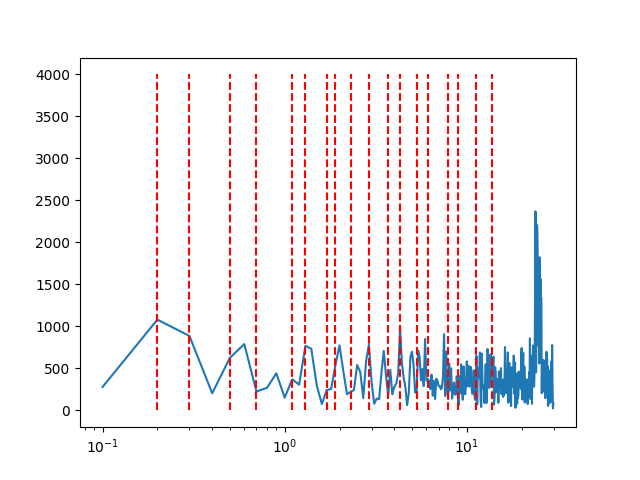

In [26]:
freqqs = np.array([0.2000,0.3000,0.5000,0.7000,1.100,1.300,1.700,1.900,2.300,2.900,3.700,4.300,5.300,6.100,7.900,8.900,11.30,13.70])

time_weights = model.get_components()[2][0].cpu().numpy()

ft_time = np.fft.fft(time_weights[1,:])
fr = np.fft.fftfreq(100000, d=1/10000)  # Assuming a sampling rate of 1000 Hz
plt.figure()
plt.plot(fr[1:300], np.abs(ft_time)[1:300])
plt.vlines(freqqs, ymin=0, ymax=4000, colors='r', linestyles='dashed')
plt.xscale('log')
plt.show()

You can also reconstruct pased on individual components:

In [77]:
# just using Muscle components
recon_mus = model.construct_single_partition(partition=1).numpy(force=True)
# using 1 of the time components
recon_time_slice = model.construct_single_component(partition=2,k=0).numpy(force=True)

Okay Lets try to Map muscles vs recon data from the 10 dimensional space to the 1 D space of Flower trajectories using OLS 

In [71]:
def OLS_projection(muscles,flower):

    # reshape to muscles x [trials x time]
    X = muscles.transpose(1,0,2).reshape(muscles.shape[1],-1).T 
    X = np.concatenate([X,np.ones(len(X))[:,np.newaxis]], axis=1) 
    Y = flower.transpose(1,0,2).reshape(flower.shape[1],-1).T
    # solve 
    weights = np.linalg.pinv(X.T @ X) @ (X.T @ Y)

    Y_pred = (X @ weights).T

    Y_pred = Y_pred.reshape(flower.transpose(1,0,2).shape).transpose(1,0,2)

    return Y_pred 

In [28]:
def OLS_projection_mean(muscles,ft):
    # reshape to muscles x [trials x time]
    X = muscles.transpose(1,0,2).reshape(muscles.shape[1],-1).T 
    X = np.concatenate([X,np.ones(len(X))[:,np.newaxis]], axis=1) 
    Y = ft.transpose(1,0,2).reshape(ft.shape[1],-1).T
    
    new_X = np.zeros((X.shape[0]//400, X.shape[1]))
    for i in range(new_X.shape[0]):
        new_X[i,:] = X[i*400:(i+1)*400,:].mean(axis=0)

    new_Y = np.zeros((Y.shape[0]//400, Y.shape[1]))
    for i in range(new_Y.shape[0]):
        new_Y[i,:] = Y[i*400:(i+1)*400,:].mean(axis=0)

    weights = np.linalg.pinv(new_X.T @ new_X) @ (new_X.T @ new_Y)
    Y_pred = (new_X @ weights).T
    #Y_pred = Y_pred.reshape(ft.transpose(1,0,2).shape).transpose(1,0,2)
    return Y_pred


In [29]:
Y = ft_dat.transpose(1,0,2).reshape(ft_dat.shape[1],-1).T
new_Y = np.zeros((Y.shape[0]//400, Y.shape[1]))
for i in range(new_Y.shape[0]):
    new_Y[i,:] = Y[i*400:(i+1)*400,:].mean(axis=0)

In [79]:

raw_map = OLS_projection(dat, ft_dat)
map_recon = OLS_projection(recon_full, ft_dat)
mus_recon = OLS_projection(recon_mus, ft_dat)
time_recon = OLS_projection(recon_time_slice, ft_dat)

In [90]:
mse = np.mean((ft_dat - map_recon)**2)
mse

np.float64(0.8984887847664065)

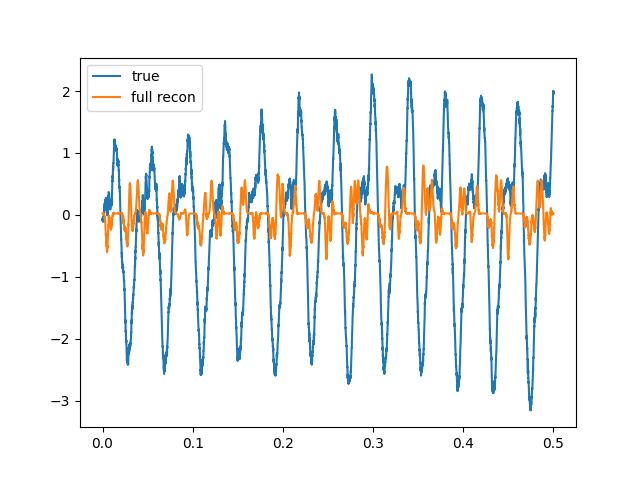

In [92]:
# plt.plot(ft_dat[0,:50], label='true')
plt.figure()
t = np.linspace(0,0.5,5000)
plt.plot(t,ft_dat[0,0,:5000], label='true')
# plt.plot(t,raw_map[0,5,:5000], label='raw')
plt.plot(t,map_recon[0,0,:5000], label='full recon')
# plt.plot(t,mus_recon[0,0,5000:10000], label='muscle recon')
# plt.plot(t,time_recon[0,5,:10000], label='time recon')
plt.legend()
plt.show() 

In [85]:
recon_mus.shape

(2, 10, 100000)

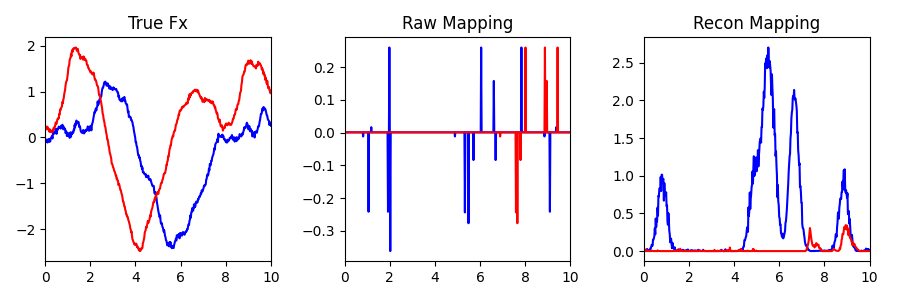

In [88]:
plot_names = ['True Fx','Raw Mapping','Recon Mapping']
trial_clors=['blue','red']
data = [ft_dat, raw_map, recon_mus]

time = np.linspace(0,10,500)
plt.figure(figsize=(9,3), dpi=100)

for di,d in enumerate(data):

    plt.subplot(1,3,di+1)
    for ti,t in enumerate(d):
        plt.plot(time, t[0,:500], color=trial_clors[ti])
    plt.title(plot_names[di])
    plt.xlim(0,10)
    # plt.ylim(100,550)

plt.tight_layout()

Grid Search For Best Number of Components 

In [67]:
train_mask,test_mask = slicetca.block_mask(dimensions=dat_tensor.shape,
                                            train_blocks_dimensions=(0,1,10),
                                            test_blocks_dimensions=(0,1,5),
                                            fraction_test=0.1,
                                            device=device)

/home/doshna/anaconda3/envs/stca/lib/python3.14/site-packages/slicetca/run/utils.py:60: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  for j in a: train_mask[j] = 0
/home/doshna/anaconda3/envs/stca/lib/python3.14/site-packages/slicetca/run/utils.py:69: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  for j in a: test_mask[

In [ ]:
loss_grid, seed_grid = slicetca.grid_search(dat_tensor,
                                            min_ranks=[0,1,0],
                                            max_ranks = [2,5,3],
                                            sample_size=2,
                                            mask_train=train_mask,
                                            mask_test = test_mask,
                                            processes_grid = 4,
                                            seed=1,
                                            min_std = 10**-4,
                                            learning_rate = 5*10**-3,
                                            max_iter=10**4,
                                            positive=True
                                            )

Grid shape: [3, 5, 4] - Samples: 2 - Grid entries: 60 - Number of models to fit: 120


Number of components (completed): (np.int64(0), np.int64(0), np.int64(2)) :   5%|▌         | 3/60 [11:36<3:40:33, 232.17s/it]
